#### **라이브러리 설치**

In [1]:
!pip install \
  "numpy>=1.24.0,<2.0.0" \
  "pandas>=2.0.0,<2.3.0" \
  "matplotlib>=3.7.0,<3.10.0" \
  "seaborn>=0.12.0,<0.14.0" \
  "koreanize-matplotlib>=0.1.1" \
  "scikit-learn>=1.2.0,<1.6.0" \
  "torch>=2.0.0,<2.6.0"

!pip install kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
^C


### **model**

In [32]:
from torch import nn, Tensor

class MultiLinearRegression(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        # nn.Linear()은 맨마지막 차원을 기준으로 연산
        self.linear_layer = nn.Linear(in_features=in_features, out_features=1)

    def forward(self, x: Tensor) -> Tensor:
        if x.ndim == 1:
            x = x.unsqueeze(1)

        return self.linear_layer(x)

### **dataset**

In [22]:
from torch.utils.data import Dataset, DataLoader
import torch

class HousingPriceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        # nn.Linear에 맞춰 안전하게 2차원으로 확장
        # -1은 와일드카드
        self.y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

In [41]:
import kagglehub
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pandas as pd

FOLDER_PATH = Path(kagglehub.dataset_download("camnugent/california-housing-prices"))
DATA_PATH = list(FOLDER_PATH.glob("*.csv"))[0]

df = pd.read_csv(DATA_PATH)
df = df.dropna().reset_index(drop=True)  # 결측치 제거
df = pd.get_dummies(df, columns=["ocean_proximity"], dtype=int)  # 원핫인코딩

X_raw = df[df.columns[df.columns != "median_house_value"]].values
y_raw = df[["median_house_value"]].values

X_train, X_temp, y_train, y_temp = train_test_split(X_raw, y_raw, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)  # train 데이터셋 평균, 표준편차를 기반으로 스케일링
y_train = scaler_y.fit_transform(y_train)

X_val   = scaler_X.transform(X_val)
y_val   = scaler_y.transform(y_val)

X_test  = scaler_X.transform(X_test)
y_test  = scaler_y.transform(y_test)

train_dataset = HousingPriceDataset(X_train, y_train)
val_dataset   = HousingPriceDataset(X_val, y_val)
test_dataset  = HousingPriceDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

Using Colab cache for faster access to the 'california-housing-prices' dataset.


### **train, validation**

In [47]:
from torch import nn, optim

in_features = len(X_train[0])
model = MultiLinearRegression(in_features)
criterion = nn.MSELoss()
optimizer = optim.SGD(params=model.parameters(), lr=0.0001)

EPOCHS = 100
for epoch in range(1, EPOCHS + 1):
    model.train()  # 훈련 모드
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(X_batch)

    avg_train_loss = train_loss / len(train_loader.dataset)

    model.eval()  # 평가 모드
    val_loss = 0.0

    with torch.no_grad(): # 기울기 계산 비활성화
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            val_loss += loss.item() * len(X_batch)

        avg_val_loss = val_loss / len(val_loader.dataset)

        if epoch % 20 == 0:
            w = model.linear_layer.weight.detach()
            b = model.linear_layer.bias.item()

            print(f"[EPOCH] {epoch} / {EPOCHS} | "
                  f"[Train Loss] {avg_train_loss:.4f} | "
                  f"[Val Loss] {avg_val_loss:.4f} | "
                  f"[Weight] {w} | [Bias] {b:.4f}")


[EPOCH] 20 / 100 | [Train Loss] 0.3631 | [Val Loss] 0.3592 | [Weight] tensor([[-0.2598, -0.2592,  0.1254,  0.0447,  0.1264, -0.3319,  0.1991,  0.6141,
          0.1881, -0.0550,  0.0252,  0.1122,  0.1452]]) | [Bias] 0.0010
[EPOCH] 40 / 100 | [Train Loss] 0.3594 | [Val Loss] 0.3541 | [Weight] tensor([[-0.3223, -0.3214,  0.1240, -0.0369,  0.2081, -0.3613,  0.2349,  0.6307,
          0.1786, -0.0357,  0.0251,  0.1064,  0.1381]]) | [Bias] 0.0001
[EPOCH] 60 / 100 | [Train Loss] 0.3583 | [Val Loss] 0.3536 | [Weight] tensor([[-0.3613, -0.3662,  0.1216, -0.0726,  0.2545, -0.3598,  0.2370,  0.6383,
          0.1760, -0.0250,  0.0248,  0.1000,  0.1331]]) | [Bias] 0.0002
[EPOCH] 80 / 100 | [Train Loss] 0.3580 | [Val Loss] 0.3520 | [Weight] tensor([[-0.3907, -0.3937,  0.1217, -0.0961,  0.2771, -0.3658,  0.2183,  0.6423,
          0.1724, -0.0176,  0.0249,  0.0987,  0.1295]]) | [Bias] -0.0004
[EPOCH] 100 / 100 | [Train Loss] 0.3577 | [Val Loss] 0.3517 | [Weight] tensor([[-0.4088, -0.4150,  0.1210, 

### **test**

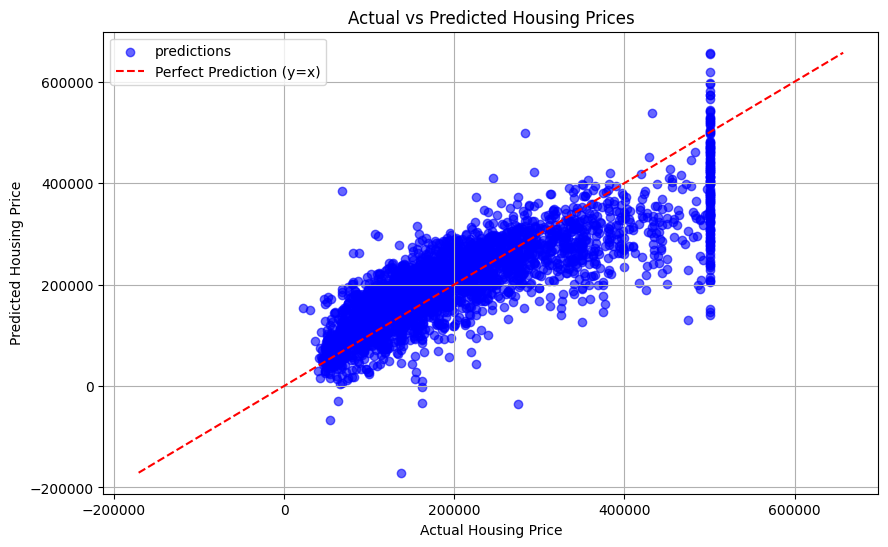

In [46]:
import torch
import matplotlib.pyplot as plt

model.eval()  # 평가 모드

test_y = []
test_y_pred = []

test_loss = 0.0

with torch.no_grad():  # 기울기 계산 비활성화
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        test_y.append(y_batch)
        test_y_pred.append(y_pred)

        test_loss += loss.item() * len(X_batch)

avg_test_loss = test_loss / len(test_loader.dataset)

test_y = torch.cat(test_y, dim=0).detach().numpy()
test_y_pred = torch.cat(test_y_pred, dim=0).detach().numpy()

actual_y = scaler_y.inverse_transform(test_y.reshape(-1, 1)).flatten()
pred_y = scaler_y.inverse_transform(test_y_pred.reshape(-1, 1)).flatten()

plt.figure(figsize=(10, 6))

plt.scatter(actual_y, pred_y, alpha=0.6, color="blue", label="predictions")

min_val = min(actual_y.min(), pred_y.min())
max_val = max(actual_y.max(), pred_y.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction (y=x)")

plt.xlabel('Actual Housing Price')
plt.ylabel('Predicted Housing Price')
plt.title('Actual vs Predicted Housing Prices')
plt.legend()
plt.grid(True)
plt.show()